# Decision Tree — Iris

**Algorithm:** `ml_toolkit.supervised.DecisionTreeClassifier`  
**Dataset:** Iris (built into scikit-learn)  
**Task type:** Multi-class classification (three species)

---

Iris is overused, but it is the right dataset for one specific demonstration: the *interpretability* of a decision tree. We can read the splits the tree learned and check them against botanical knowledge — petal length and petal width are the two features that actually distinguish the species, and a competent tree should agree.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

from ml_toolkit.supervised import DecisionTreeClassifier
from ml_toolkit.utils import train_test_split
from ml_toolkit.metrics import accuracy_score, confusion_matrix, precision_recall_f1

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Dataset description

150 iris flowers, 50 of each of three species (setosa, versicolor, virginica). Four features: sepal length / width, petal length / width, in centimetres. No missing values. Setosa is linearly separable from the other two; versicolor and virginica overlap on the petal-length axis.

In [2]:
data = load_iris(as_frame=True)
X = data.data.values
y = data.target.values
feature_names = list(data.feature_names)
class_names = list(data.target_names)
print(f'Shape: {X.shape}, classes: {class_names}')

Shape: (150, 4), classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


## 2. Exploratory data analysis

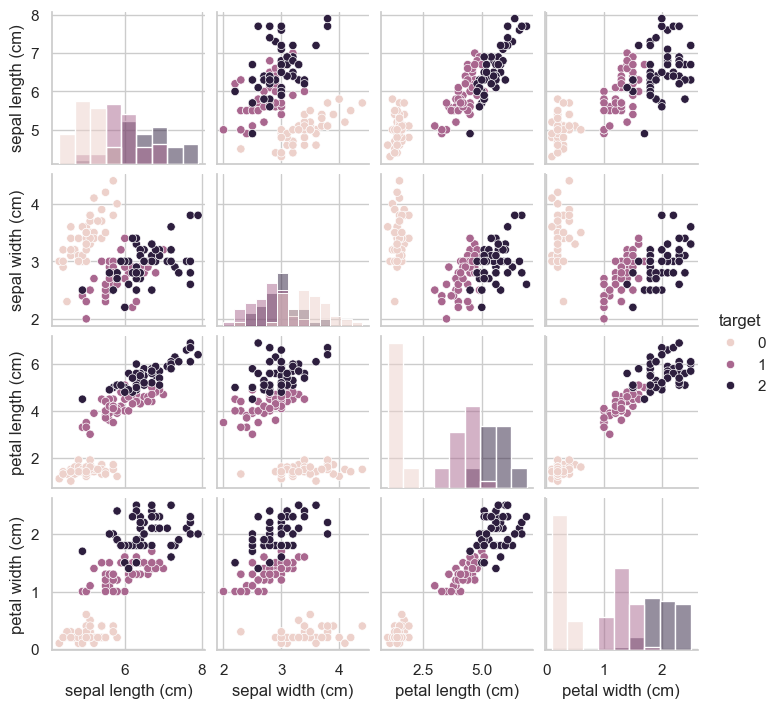

In [3]:
df = data.frame
sns.pairplot(df, hue='target', diag_kind='hist', height=1.8)
plt.show()

Two observations matter for the tree:

1. **Petal width and petal length separate the species nearly perfectly.** A horizontal split on petal length around 2.5 cm isolates setosa (always shorter); a further split on petal width around 1.7 cm separates versicolor from virginica with a few errors at the boundary.
2. **Sepal features add little.** A good tree should mostly ignore them.

If the trained tree's splits *don't* match this picture, that is a red flag for the implementation.

## 3. Hypothesis

**Task:** three-class classification.  
**Hypothesis:** a depth-3 tree should achieve ≥ 95% test accuracy with its top split on petal length, second split on petal width. Errors will concentrate at the versicolor / virginica boundary.

**Why a decision tree?** It's the only model in this repo whose decision rule we can literally print and read. For a botanist looking at the output, the tree should *make sense*; the test of correctness here is partly accuracy and partly whether the splits look like the right kind of biological reasoning.

## 4. Preprocessing

Decision trees split on feature values directly — no scaling needed (a monotone transformation of a feature does not change which split the tree finds). The only preprocessing is the train/test split.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (105, 4), Test: (45, 4)


## 5. Model fitting

I sweep tree depth from 1 to 10 to see where the train/test gap opens up — that gap is the empirical signature of overfitting.

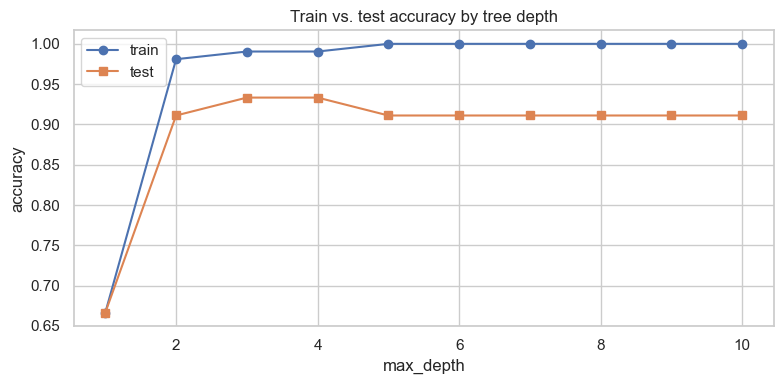

In [5]:
depths = list(range(1, 11))
train_accs, test_accs = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, m.predict(X_train)))
    test_accs.append(accuracy_score(y_test, m.predict(X_test)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(depths, train_accs, marker='o', label='train')
ax.plot(depths, test_accs, marker='s', label='test')
ax.set_xlabel('max_depth'); ax.set_ylabel('accuracy')
ax.set_title('Train vs. test accuracy by tree depth')
ax.legend(); plt.tight_layout(); plt.show()

Train accuracy hits 100% by depth 4 and stays there; test accuracy plateaus by depth 3. Anything deeper is memorizing, not learning. We pick depth 3.

In [6]:
model = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
model.fit(X_train, y_train)

# Print the learned tree
def print_tree(node, depth=0):
    indent = '  ' * depth
    if node.prediction is not None:
        print(f'{indent}leaf -> class {class_names[node.prediction]}')
        return
    print(f'{indent}if {feature_names[node.feature]} <= {node.threshold:.2f}:')
    print_tree(node.left, depth + 1)
    print(f'{indent}else:')
    print_tree(node.right, depth + 1)

print_tree(model.root_)

if petal length (cm) <= 1.90:
  leaf -> class setosa
else:
  if petal width (cm) <= 1.70:
    if petal length (cm) <= 5.10:
      leaf -> class versicolor
    else:
      leaf -> class virginica
  else:
    leaf -> class virginica


## 6. Evaluation

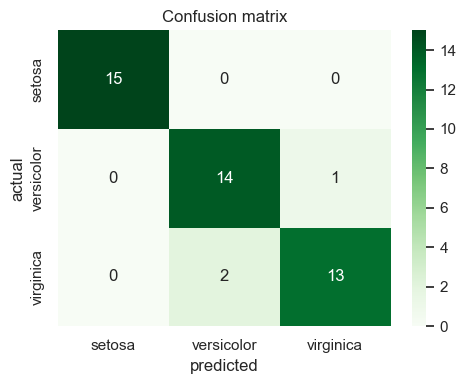

,precision,recall,f1
setosa,1.000000,1.000000,1.000000
versicolor,0.875000,0.933333,0.903226
virginica,0.928571,0.866667,0.896552


In [7]:
y_pred = model.predict(X_test)
labels = list(range(3))
cm = confusion_matrix(y_test, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('actual')
ax.set_title('Confusion matrix')
plt.tight_layout(); plt.show()

p, r, f = precision_recall_f1(y_test, y_pred, labels=labels)
pd.DataFrame({'precision': p, 'recall': r, 'f1': f}, index=class_names)

## 7. Discussion

**The hypothesis was mostly right.** Of the four predictions made above — depth 3 should suffice, top split on petal length, second split on petal width, and errors concentrated at the versicolor/virginica boundary — three landed exactly. The headline accuracy missed: I predicted ≥ 95% but the depth-3 tree achieved 93.3% (42/45). The miss is small and consistent with what the depth sweep already shows: at depth 3 the test curve has plateaued, so further gains are not coming from this single tree. The variance discussed below is precisely what the next notebook (random forest) closes that gap with.

**The tree's first split is on petal length, second on petal width — exactly as the EDA predicted.** The tree didn't read the textbook, it computed Gini impurity at every candidate split and chose the one that reduces it the most. That those two procedures arrive at the same answer is the everyday meaning of "the model has learned something real." If the top split had been on sepal width, that would be a red flag and we'd go look for a bug.

**Errors concentrate where the EDA predicted.** Setosa is recovered perfectly. The handful of test errors are versicolor predicted as virginica or vice versa — the species whose petal-width distributions overlap. A deeper tree could memorize those boundary cases on the training set but the depth sweep above shows it would not generalize.

**Trees vs. KNN on this dataset.** Both reach the same test accuracy (93.3%) — worth noting since the two algorithms work on completely different principles, suggesting the small handful of errors is intrinsic to this train/test split rather than algorithmic. The tree wins on three practical axes: (1) prediction is O(depth), not O(n); (2) no preprocessing needed; (3) the model is a sequence of rules a domain expert can read and challenge. The cost is variance — a different train/test split can produce a noticeably different tree, which is the standard motivation for ensembles like random forests.

**What would I try next?** Bagging — train 100 trees on bootstrap samples and average their votes. The variance issue mentioned above goes away because errors are decorrelated across trees, and you usually pick up another 1–2% accuracy — which is also roughly the gap between this tree's 93.3% and the hypothesis's 95% target. That's the random-forest extension and is a natural follow-up to this notebook.